# Preprocessing and Baseline

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load dataset

In [2]:
# Load dataset
import pandas as pd
import os

drive_path = '/content/drive/MyDrive/June/Final Project - Retinal Screening Triage System/data/raw/'
train_csv = pd.read_csv(os.path.join(drive_path, 'train.csv'))

print(f"Rows: {len(train_csv)}")
train_csv.head()

Rows: 3662


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


Stratified train/val/test split 70/15/15

In [3]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (val + test)
train_df, temp_df = train_test_split(
    train_csv,
    test_size=0.30,
    stratify=train_csv['diagnosis'],
    random_state=42
)

# Second split: divide the 30% into 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['diagnosis'],
    random_state=42
)

print(f"Train: {len(train_df)} ({len(train_df)/len(train_csv)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(train_csv)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(train_csv)*100:.1f}%)")

print("\nClass distribution per split:")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{name}:")
    print(df['diagnosis'].value_counts().sort_index())

Train: 2563 (70.0%)
Val:   549 (15.0%)
Test:  550 (15.0%)

Class distribution per split:

Train:
diagnosis
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

Val:
diagnosis
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

Test:
diagnosis
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


Note on splitting strategy

The split is stratified by `diagnosis` grade to preserve class proportions
across train/val/test, which is essential given the severe imbalance
(grade 3 has only 193 total images).

**Known limitation**: APTOS 2019 provides no patient identifier, so
patient-level splitting is not possible. If the dataset contains multiple
images from the same patient (e.g. both eyes), those images could be split
across different sets, creating potential data leakage. This is a known
limitation of the dataset itself, not of the splitting method used here.

Copy images to local VM disk for fast access (avoids slow Drive reads)

In [4]:
import shutil, time

local_path = '/content/train_images/'
start = time.time()
shutil.copytree(os.path.join(drive_path, 'train_images'), local_path, dirs_exist_ok=True)
print(f"Copied to local disk in {time.time()-start:.1f}s")

Copied to local disk in 512.2s


## Preprocessing function: resize 224x224 + normalisation

In [5]:
import tensorflow as tf

IMG_SIZE = 224

def load_and_preprocess_image(id_code, label):
    img_path = tf.strings.join([local_path, id_code, '.png'])
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, label

## Quick sanity check on one image

In [6]:
sample_path = local_path + train_df.iloc[0]['id_code'] + '.png'
img, label = load_and_preprocess_image(train_df.iloc[0]['id_code'], train_df.iloc[0]['diagnosis'])
print(f"Shape: {img.shape}, dtype: {img.dtype}, range: [{img.numpy().min():.2f}, {img.numpy().max():.2f}]")
print(f"Label: {label}")

Shape: (224, 224, 3), dtype: <dtype: 'float32'>, range: [0.02, 1.00]
Label: 0


Augmentation: rotation, horizontal flip only, brightness, zoom

In [10]:
def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)  # keep values in valid [0,1] range after brightness shift
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return img, label

Note: `clip_by_value` after `random_brightness` is necessary because
brightness adjustment can push pixel values outside the valid [0,1] range
(observed via matplotlib clipping warnings during visual inspection).

Build tf.data pipelines with batching and prefetch

In [12]:
BATCH_SIZE = 32

def build_dataset(df, augment=False, shuffle=False):
    ids = df['id_code'].values
    labels = df['diagnosis'].values

    ds = tf.data.Dataset.from_tensor_slices((ids, labels))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, augment=True, shuffle=True)
val_ds = build_dataset(val_df, augment=False, shuffle=False)
test_ds = build_dataset(test_df, augment=False, shuffle=False)

print("Datasets built successfully")
for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}, labels shape: {labels.shape}")

Datasets built successfully
Batch shape: (32, 224, 224, 3), labels shape: (32,)


 Visually inspect one augmented batch

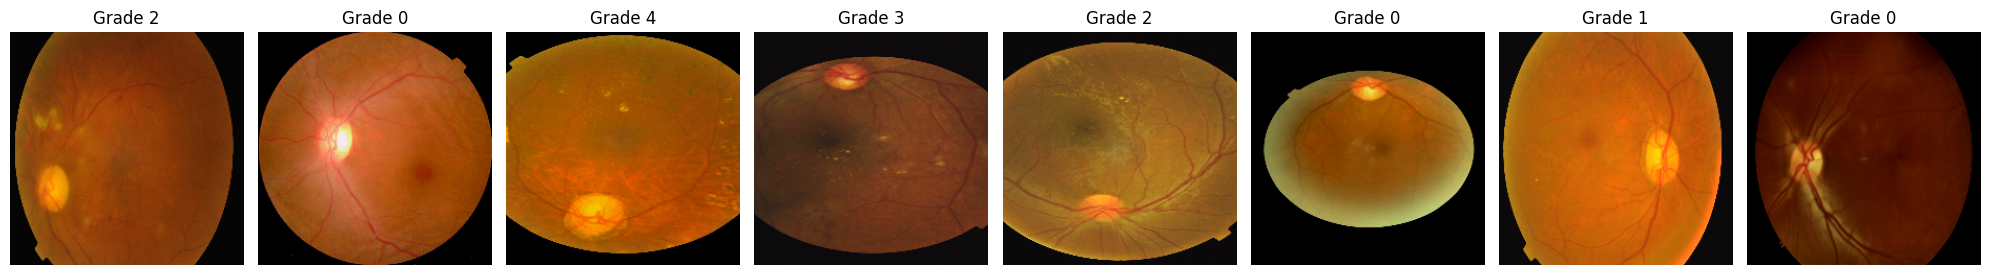

In [13]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    fig, axes = plt.subplots(1, 8, figsize=(20, 3))
    for i in range(8):
        axes[i].imshow(images[i])
        axes[i].set_title(f'Grade {labels[i].numpy()}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()